# Classification Evaluation Metrics

We have built a Logistic Regression model.

Now the important question is

"How good is our model?"

We need evaluation metrics to measure the performance of a classification model.

In this notebook we will learn

• Confusion Matrix

• Accuracy

• Precision

• Recall

• F1 Score

• ROC Curve

• AUC

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.DataFrame({

    "Income":[3,8,3,8,5,7,6,4,10,2,9,6],

    "CreditScore":[520,520,720,720,650,650,700,750,580,800,760,680],

    "Experience":[1,1,1,3,2,5,2,6,8,7,6,4],

    "Approved":[0,0,0,1,0,1,1,1,1,1,1,1]

})

df

,Income,CreditScore,Experience,Approved
0,3,520,1,0
1,8,520,1,0
2,3,720,1,0
3,8,720,3,1
4,5,650,2,0
5,7,650,5,1
6,6,700,2,1
7,4,750,6,1
8,10,580,8,1
9,2,800,7,1


In [3]:
from sklearn.model_selection import train_test_split
X = df[["Income","CreditScore","Experience"]]

y = df["Approved"]
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.3,
    random_state=42

)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print(y_pred)
print(y_test.values)

[1 1 0 1]
[1 1 0 1]


# Confusion Matrix

How many predictions are correct?

How many are wrong?

In [4]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[1 0]
 [0 3]]


## Confusion Matrix

A Confusion Matrix compares the **actual values** with the **predicted values**.

| **Actual \ Predicted** | **0 (Rejected)** | **1 (Approved)** |
|:----------------------:|:----------------:|:----------------:|
| **0 (Rejected)** | **True Negative (TN)** | **False Positive (FP)** |
| **1 (Approved)** | **False Negative (FN)** | **True Positive (TP)** |

### Interpretation

- **True Positive (TP)**  
  The customer was actually approved, and the model predicted **Approved**.

- **True Negative (TN)**  
  The customer was actually rejected, and the model predicted **Rejected**.

- **False Positive (FP)**  
  The customer was actually rejected, but the model predicted **Approved**.

- **False Negative (FN)**  
  The customer was actually approved, but the model predicted **Rejected**.

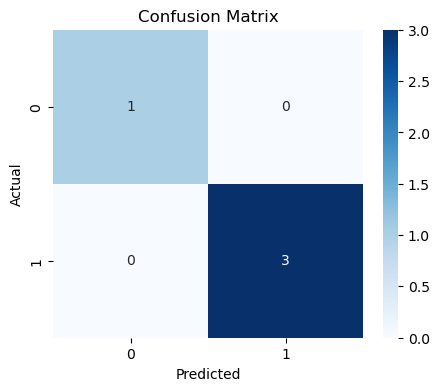

In [5]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Accuracy = Correct Predictions  / Total Predictions
The ratio of correct predictions to the total number of predictions.

in confusion matrix terms - ( True Positive + True Negatives ) / Total Prediction

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

1.0


# Precision 
The ratio of correctly predicted positive observations to the total predicted positives. It answers: When the model predicts a positive result, how often is it actually right?

in terms of Confusion matrix - True Positive / ( True Positive + False Positives)

In [8]:
from sklearn.metrics import precision_score

precision = precision_score(

    y_test,

    y_pred

)

print(precision)

1.0


# Recall
Recall is a machine learning metric that measures a model's 
ability to identify all relevant instances in a dataset.
 It answers the question: "Out of all the actual positive cases, 
how many did the model correctly find?" It is also known as the
 True Positive Rate (TPR) 
or Sensitivity

Recall = True Positive / (True Positive + False Negative)

In [9]:
from sklearn.metrics import recall_score

recall = recall_score(

    y_test,

    y_pred

)

print(recall)

1.0


# F1 Score
The F1 score is a machine learning evaluation metric that 
measures a model's accuracy by calculating the harmonic mean 
of precision and recall. 
Ranging from 0 (worst) to 1 (perfect), it is essential for imbalanced 
datasets where standard 
accuracy can be misleading

F1 = 2 * ( (Precision * Recall ) / ( Precision + Recall ) )

Unlike a standard arithmetic average, the harmonic mean penalizes extreme values heavily. If your model has 100% precision but only 10% recall, a standard average yields 55%, which hides the model's severe flaw in missing 90% of the positive cases. The harmonic mean drops the score to around 18.2%, providing a more realistic assessment. Both precision and recall must be high for a good F1

In [10]:
from sklearn.metrics import f1_score

f1 = f1_score(

    y_test,

    y_pred

)

print(f1)

1.0


# Probability

In [11]:
probability = model.predict_proba(X_test)

print(probability)

[[7.12686905e-05 9.99928731e-01]
 [3.77885023e-03 9.96221150e-01]
 [9.99921542e-01 7.84583255e-05]
 [1.05430341e-02 9.89456966e-01]]


# ROC Curve

Instead of Threshold = 0.5

What happens if we change it?

In [12]:
from sklearn.metrics import roc_curve

from sklearn.metrics import auc

In [13]:
probability = model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(

    y_test,

    probability

)

roc_auc = auc(

    fpr,

    tpr

)

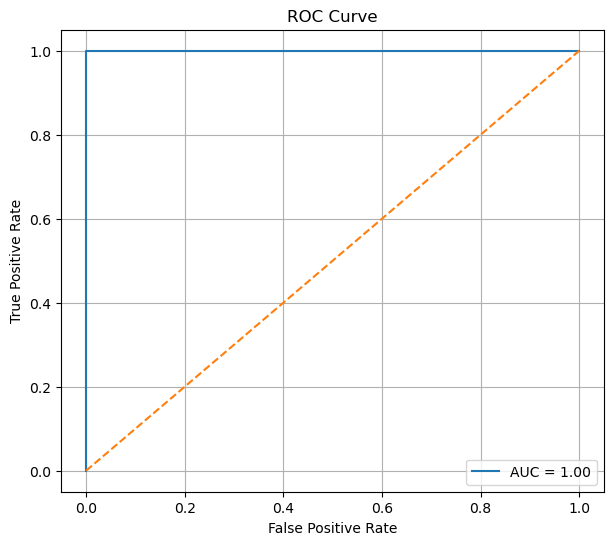

In [ ]:
plt.figure(figsize=(7,6))
plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.2f}"

)

plt.plot(

    [0,1],

    [0,1],

    '--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()